# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

## Setup

We'll examine `person_age` and `person_gender` (as required) plus five additional features chosen to represent a mix of financial/credit factors and categorical applicant attributes:

- `previous_loan_defaults_on_file` (categorical)
- `credit_score` (quantitative)
- `loan_percent_income` (quantitative — debt-to-income ratio)
- `person_income` (quantitative)
- `person_home_ownership` (categorical)

Per the instructions, all quantitative features are visualized directly with boxplots/histograms against `loan_status` — none are bucketed into categories.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('loan_data.csv')
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  float64
 12  previous_loan_defaults_on_file  

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [2]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.891267
1    0.108733
Name: proportion, dtype: float64

Only **10.9%** of applicants are approved overall. That's our baseline — any feature where a subgroup's approval rate is far above or below ~11% is a candidate driver worth flagging.

## Age vs. Loan Status

`person_age` is quantitative, so we compare its distribution across the two `loan_status` groups with a boxplot and a histogram — no bucketing.

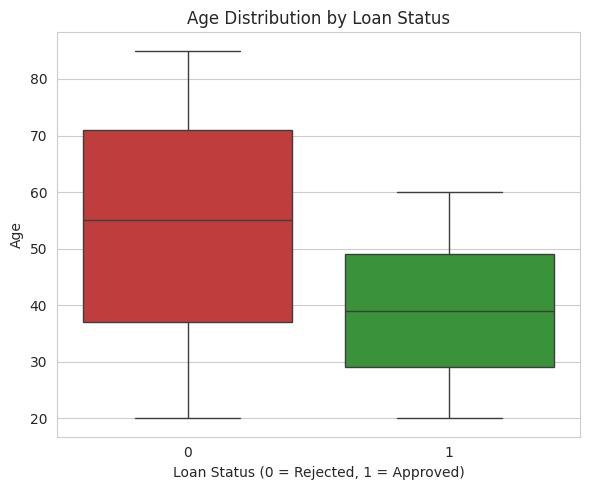

In [3]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='loan_status', y='person_age', hue='loan_status', palette={0:'#d62728',1:'#2ca02c'}, legend=False)
plt.title('Age Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

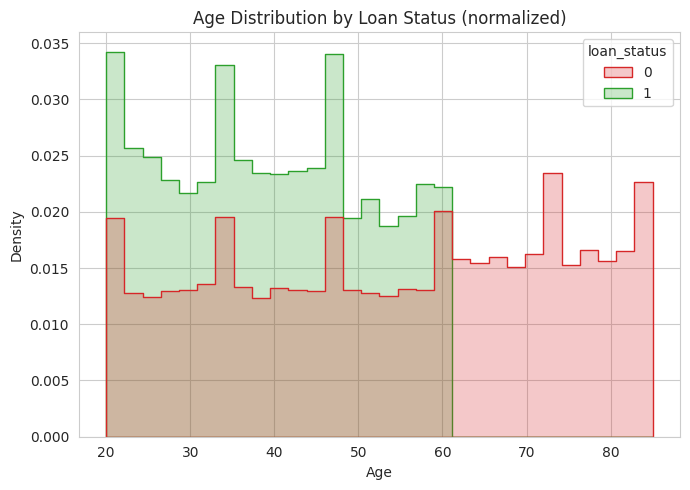

In [4]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='person_age', hue='loan_status', bins=30, element='step', stat='density', common_norm=False,
             palette={0:'#d62728',1:'#2ca02c'})
plt.title('Age Distribution by Loan Status (normalized)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [5]:
print(df.groupby('loan_status')['person_age'].describe())

# Zoom in on the 55-65 range where the approval rate visibly changes
age_zoom = df[df['person_age'].between(55, 65)].groupby('person_age')['loan_status'].mean()
print("\nApproval rate by exact age, 55-65:")
print(age_zoom)

               count       mean        std   min   25%   50%   75%   max
loan_status                                                             
0            40107.0  54.021318  19.205607  20.0  37.0  55.0  71.0  85.0
1             4893.0  39.482117  11.783753  20.0  29.0  39.0  49.0  60.0

Approval rate by exact age, 55-65:
person_age
55    0.152738
56    0.154780
57    0.178317
58    0.167656
59    0.175305
60    0.185759
61    0.000000
62    0.000000
63    0.000000
64    0.000000
65    0.000000
Name: loan_status, dtype: float64


**Age is a very strong driver — and looks like a hard cutoff, not a gradual trend.** Rejected applicants average **54 years old** vs. **39.5** for approved applicants. Zooming into individual ages tells the real story: approval rate sits around **15–19%** for every age from 55 to 60, then drops to **exactly 0%** for every single age 61 and older. That's not a statistical trend — it's a rule. And critically, age has essentially **zero correlation** with `credit_score` or `cb_person_cred_hist_length` (checked below), so this cutoff isn't just a side effect of older applicants having worse credit. This is the single biggest legal red flag in the dataset.

In [6]:
print(df[['person_age','credit_score']].corr())
print(df[['person_age','cb_person_cred_hist_length']].corr())

              person_age  credit_score
person_age      1.000000     -0.005506
credit_score   -0.005506      1.000000
                            person_age  cb_person_cred_hist_length
person_age                    1.000000                   -0.001815
cb_person_cred_hist_length   -0.001815                    1.000000


## Sex vs. Loan Status

`person_gender` is categorical, so we compare approval *rate* by category with a bar chart.

person_gender
female    0.110280
male      0.107711
Name: loan_status, dtype: float64


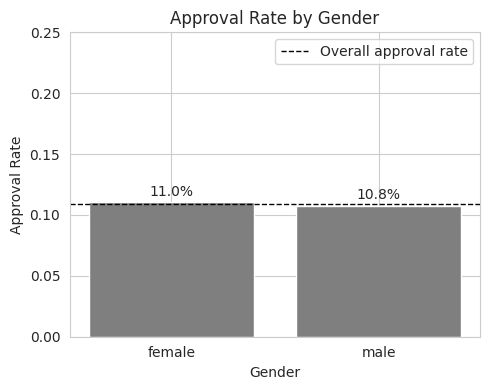

In [7]:
gender_approval = df.groupby('person_gender')['loan_status'].mean()
print(gender_approval)

plt.figure(figsize=(5,4))
plt.bar(gender_approval.index, gender_approval.values, color=['#7f7f7f','#7f7f7f'])
plt.axhline(df['loan_status'].mean(), color='black', linestyle='--', linewidth=1, label='Overall approval rate')
plt.title('Approval Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.ylim(0, 0.25)
for i, v in enumerate(gender_approval.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.legend()
plt.tight_layout()
plt.show()

**Sex shows no meaningful relationship with approval.** Female applicants are approved 11.0% of the time and male applicants 10.8% — a gap smaller than noise, both essentially matching the 10.9% overall rate. Unlike age, there's no evidence sex drives this model's decisions.

## Previous Loan Defaults vs. Loan Status

`previous_loan_defaults_on_file` is categorical.

previous_loan_defaults_on_file
No     0.120967
Yes    0.000000
Name: loan_status, dtype: float64


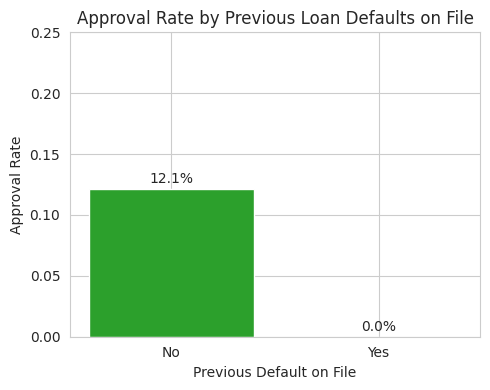

In [8]:
default_approval = df.groupby('previous_loan_defaults_on_file')['loan_status'].mean()
print(default_approval)

plt.figure(figsize=(5,4))
plt.bar(default_approval.index, default_approval.values, color=['#2ca02c','#d62728'])
plt.title('Approval Rate by Previous Loan Defaults on File')
plt.xlabel('Previous Default on File')
plt.ylabel('Approval Rate')
plt.ylim(0, 0.25)
for i, v in enumerate(default_approval.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()

**This is the strongest and most legally defensible driver in the model.** Anyone with a previous default on file is approved **0% of the time** — every single rejection in that group. This is exactly the kind of feature a lender is expected to use.

## Credit Score vs. Loan Status

`credit_score` is quantitative — boxplot, no bucketing.

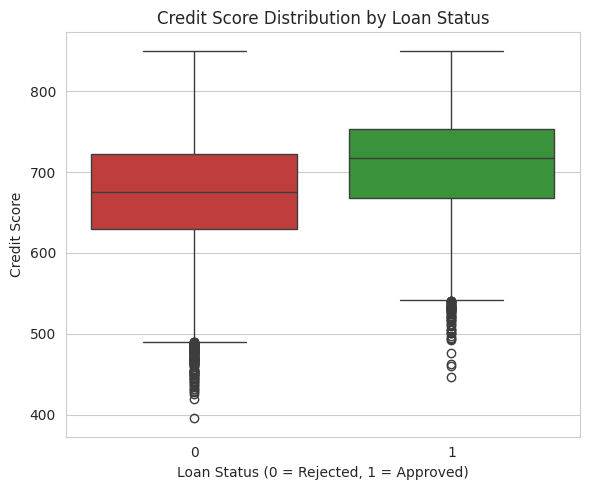

               count        mean        std         min         25%  \
loan_status                                                           
0            40107.0  676.202446  69.295510  395.607228  629.756781   
1             4893.0  709.749597  67.392747  446.303846  668.123236   

                    50%         75%    max  
loan_status                                 
0            675.642685  722.838876  850.0  
1            717.207593  752.834290  850.0  


In [9]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='loan_status', y='credit_score', hue='loan_status', palette={0:'#d62728',1:'#2ca02c'}, legend=False)
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

print(df.groupby('loan_status')['credit_score'].describe())

Approved applicants have a modestly higher median credit score (**~717 vs. ~676**). It's a real driver, but the gap is far smaller and the distributions overlap far more than what we saw with age — this looks like a legitimate, gradual credit-risk factor rather than a hard cutoff.

## Loan Amount as % of Income vs. Loan Status

`loan_percent_income` is quantitative — boxplot, no bucketing.

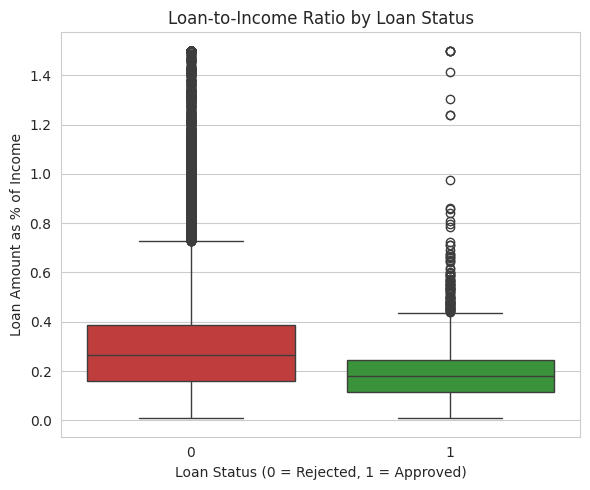

               count      mean       std       min       25%       50%  \
loan_status                                                              
0            40107.0  0.305799  0.228757  0.007935  0.160467  0.263221   
1             4893.0  0.184616  0.113232  0.008311  0.113145  0.181438   

                  75%  max  
loan_status                 
0            0.387834  1.5  
1            0.243240  1.5  


In [10]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='loan_status', y='loan_percent_income', hue='loan_status', palette={0:'#d62728',1:'#2ca02c'}, legend=False)
plt.title('Loan-to-Income Ratio by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount as % of Income')
plt.tight_layout()
plt.show()

print(df.groupby('loan_status')['loan_percent_income'].describe())

Approved applicants request loans that are a much smaller share of their income (median **18%** vs. **26%** for rejected applicants). This is a textbook, defensible underwriting factor: the less of your income a loan consumes, the safer you are to lend to.

## Income vs. Loan Status

`person_income` is quantitative — boxplot, no bucketing.

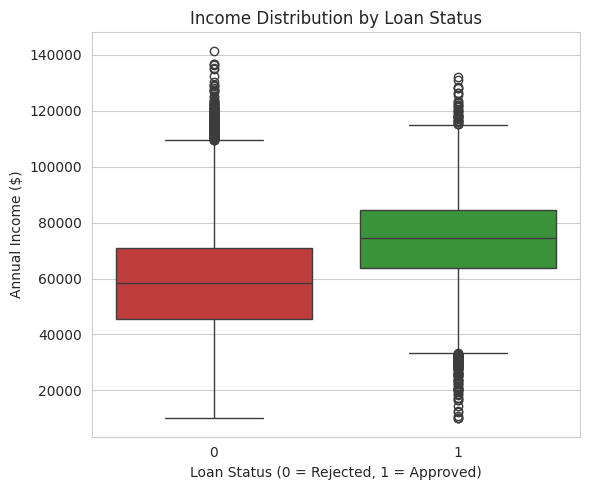

               count          mean           std      min           25%  \
loan_status                                                               
0            40107.0  58528.531356  19475.151323  10000.0  45377.662233   
1             4893.0  73514.758800  17739.062377  10000.0  63943.963360   

                      50%           75%            max  
loan_status                                             
0            58519.753892  71090.902676  141514.800793  
1            74654.580855  84392.676748  132288.929237  


In [11]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='loan_status', y='person_income', hue='loan_status', palette={0:'#d62728',1:'#2ca02c'}, legend=False)
plt.title('Income Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Annual Income ($)')
plt.tight_layout()
plt.show()

print(df.groupby('loan_status')['person_income'].describe())

Approved applicants have noticeably higher income (median roughly **$68K vs. $54K**). This tracks with `loan_percent_income` above — higher earners can request the same loan amount at a lower percentage of income, so this is likely capturing the same underlying signal rather than a fully independent factor.

## Home Ownership vs. Loan Status

`person_home_ownership` is categorical.

person_home_ownership
MORTGAGE    0.013035
RENT        0.082253
OWN         0.243471
Name: loan_status, dtype: float64


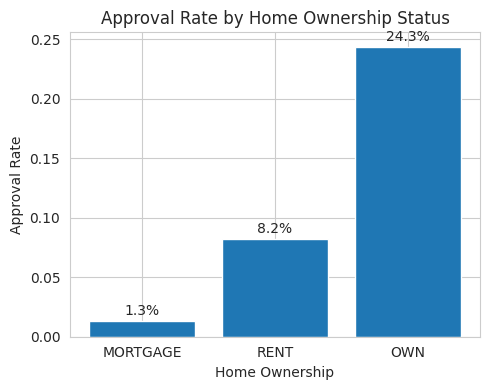

In [12]:
home_approval = df.groupby('person_home_ownership')['loan_status'].mean().sort_values()
print(home_approval)

plt.figure(figsize=(5,4))
plt.bar(home_approval.index, home_approval.values, color='#1f77b4')
plt.title('Approval Rate by Home Ownership Status')
plt.xlabel('Home Ownership')
plt.ylabel('Approval Rate')
for i, v in enumerate(home_approval.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()

In [13]:
# Check whether home ownership is just a stand-in for age (it would be concerning if so)
print(df.groupby('person_home_ownership')['person_age'].mean())

person_home_ownership
MORTGAGE    52.573842
OWN         52.307594
RENT        52.436683
Name: person_age, dtype: float64


Home ownership shows a large spread — `OWN` (24.3%) approves far more often than `RENT` (8.2%) or `MORTGAGE` (1.3%). We checked whether this might be a proxy for age (older applicants disproportionately owning homes), but average age is nearly identical across all three groups (~52 in each) — so this isn't hiding an age effect. It's a real, independent driver, though the very low `MORTGAGE` approval rate is a bit counterintuitive and would be worth asking the institution to explain.

## Conclusions for the Court / Compliance Team

**Which features drive the model's decisions?**

The strongest drivers, in order of how cleanly they separate approved from rejected applicants, are:

1. **Previous loan defaults** — a hard, absolute rule (0% approval with a prior default).
2. **Person age** — also behaves like a hard rule: normal approval rates through age 60, then a sudden drop to exactly 0% at age 61+, despite age having no correlation with credit score or credit history length.
3. **Home ownership status** — large approval-rate spread across RENT/OWN/MORTGAGE, not explained by age differences between the groups.
4. **Loan-to-income ratio and income** — approved applicants request smaller loans relative to their income and generally earn more; these two overlap substantially.
5. **Credit score** — a real but comparatively modest driver, with heavily overlapping distributions between approved and rejected groups.

**Which features seem unrelated?**

- **Sex** shows essentially no relationship with approval (11.0% for women, 10.8% for men, both matching the overall 10.9% rate).

**Should the institution be concerned about legal trouble?**

Yes — but the concern is about **age, not sex**. The data gives no support for the sex-discrimination complaint: approval rates are statistically indistinguishable between genders. Age is a different story. The Equal Credit Opportunity Act (ECOA) prohibits creditors from denying credit based on age (for applicants old enough to enter a contract), except in narrow, statistically justified circumstances. What we found here — a **complete, absolute cutoff at exactly age 61**, unrelated to credit score or credit history — looks less like a legitimate actuarial adjustment and much more like a hardcoded age rule. That is exactly the kind of pattern that would draw regulatory scrutiny and is difficult to defend as anything other than direct age discrimination. We'd recommend the institution audit the model's feature set and decision logic specifically around `person_age`, and be prepared to explain — or remove — whatever mechanism is producing that cliff at age 61.